
# Triadic Cell Notebook v27
## Calibrated retrieve/grow split: 35 / 65

This notebook continues directly from v26.

v26 proved the triad:

- **shape**
- **complement**
- **declared value**

and showed that the same query shape can either:
- retrieve something that already exists
- or expose the missing complement of something partial

v27 adds one thing:

## explicit mode calibration

We want the controller to operate at:

- **35% retrieve**
- **65% grow**

So instead of using only a fixed local rule for `retrieve` vs `grow`, we compute a
**closure score** and calibrate its threshold so that the runtime prefers growth more often.

This is the right next step if the system is still retrieving too early on partial inputs.



## Practical meaning

The triad stays the same:

$$
Q \to (\text{best closure},\ \text{missing complement},\ \text{declared value})
$$

But now we explicitly tune the controller so that:
- only the strongest closure cases retrieve
- the rest stay in grow mode

That is a direct way to push the runtime toward:
- less premature collapse
- more complement-first behavior


In [1]:

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.



## Canonical triadic chain


In [2]:

n_classes = 4
dim = 6

base_molds = np.array([
    [
        [0.95, 0.15, 0.10, 0.20, 0.30, 0.10],
        [0.70, 0.25, 0.45, 0.30, 0.45, 0.20],
        [0.55, 0.20, 0.60, 0.25, 0.70, 0.35],
    ],
    [
        [0.10, 0.95, 0.15, 0.25, 0.10, 0.30],
        [0.25, 0.72, 0.25, 0.50, 0.25, 0.45],
        [0.20, 0.58, 0.30, 0.70, 0.30, 0.72],
    ],
    [
        [0.20, 0.10, 0.95, 0.15, 0.25, 0.12],
        [0.45, 0.25, 0.75, 0.30, 0.42, 0.22],
        [0.62, 0.22, 0.55, 0.25, 0.72, 0.30],
    ],
    [
        [0.15, 0.22, 0.18, 0.95, 0.12, 0.35],
        [0.28, 0.42, 0.25, 0.75, 0.22, 0.58],
        [0.35, 0.72, 0.30, 0.60, 0.25, 0.78],
    ],
], dtype=float)

def normalize01(x):
    return np.clip(x, 0.0, 1.0)

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def chain_mix(prev_shape: np.ndarray, local_mold: np.ndarray, alpha: float = 0.58):
    return normalize01(alpha * prev_shape + (1.0 - alpha) * local_mold)

def build_chain_for_class(cls: int):
    s0 = normalize01(base_molds[cls, 0].copy())
    s1 = chain_mix(s0, base_molds[cls, 1], alpha=0.58)
    s2 = chain_mix(s1, base_molds[cls, 2], alpha=0.58)
    return [s0, s1, s2]

chains = {cls: build_chain_for_class(cls) for cls in range(n_classes)}



## Query corruption


In [3]:

QUERY_MODES = ["existing", "partial", "noisy", "ambiguous", "inverse_hint"]
QUERY_WEIGHTS = np.array([0.28, 0.28, 0.18, 0.16, 0.10], dtype=float)
QUERY_WEIGHTS = QUERY_WEIGHTS / QUERY_WEIGHTS.sum()

def make_query(cls: int, mode: str):
    target = chains[cls][0].copy()
    q = target.copy()

    if mode == "existing":
        q += rng.normal(0.0, 0.02, size=q.shape[0])

    elif mode == "partial":
        mask = rng.random(q.shape[0]) < 0.40
        q[mask] = 0.0
        q += rng.normal(0.0, 0.02, size=q.shape[0])

    elif mode == "noisy":
        q += rng.normal(0.0, 0.08, size=q.shape[0])

    elif mode == "ambiguous":
        alt = int((cls + rng.integers(1, n_classes)) % n_classes)
        q = 0.58 * target + 0.42 * chains[alt][0] + rng.normal(0.0, 0.03, size=q.shape[0])

    elif mode == "inverse_hint":
        inv = 1.0 - target
        q = 0.65 * target + 0.35 * inv + rng.normal(0.0, 0.03, size=q.shape[0])
        mask = rng.random(q.shape[0]) < 0.20
        q[mask] = 0.0

    return normalize01(q)



## Triadic evaluation

Same runtime as v26, plus a closure score used for calibration.


In [4]:

def triadic_evaluate(query: np.ndarray, cls: int):
    s0, s1, s2 = chains[cls]

    retrieve_fit = cosine_similarity(query, s0)

    missing = normalize01(np.maximum(s0 - query, 0.0))
    excess = normalize01(np.maximum(query - s0, 0.0))
    residual_energy = float(np.mean(np.abs(s0 - query)))

    folded0 = normalize01(query + missing - 0.25 * excess)

    projected1 = chain_mix(folded0, base_molds[cls, 1], alpha=0.58)
    projected2 = chain_mix(projected1, base_molds[cls, 2], alpha=0.58)

    bridge_energy = (
        0.40 * residual_energy
        + 0.20 * np.mean(missing)
        + 0.20 * np.mean(excess)
        + 0.20 * (1.0 - retrieve_fit)
    )

    closure_score = (
        0.70 * retrieve_fit
        - 0.85 * bridge_energy
        - 0.45 * np.mean(missing)
        - 0.25 * residual_energy
    )

    return {
        "class": cls,
        "retrieve_fit": float(retrieve_fit),
        "residual_energy": float(residual_energy),
        "bridge_energy": float(bridge_energy),
        "closure_score": float(closure_score),
        "missing": missing,
        "excess": excess,
        "folded0": folded0,
        "projected1": projected1,
        "declared_value": projected2,
    }

def triadic_query(query: np.ndarray):
    results = [triadic_evaluate(query, cls) for cls in range(n_classes)]
    results = sorted(results, key=lambda r: r["closure_score"], reverse=True)

    best = results[0]
    second = results[1]
    margin = float(best["closure_score"] - second["closure_score"])

    return best, results, margin



## Build calibration / evaluation world


In [5]:

rows = []
n_per_class = 700

for cls in range(n_classes):
    for _ in range(n_per_class):
        mode = rng.choice(QUERY_MODES, p=QUERY_WEIGHTS)
        q = make_query(cls, mode)
        best, all_results, margin = triadic_query(q)

        rows.append({
            "true_class": cls,
            "query_mode": mode,
            "predicted_class": best["class"],
            "correct": int(best["class"] == cls),
            "margin": margin,
            "retrieve_fit": best["retrieve_fit"],
            "residual_energy": best["residual_energy"],
            "bridge_energy": best["bridge_energy"],
            "closure_score": best["closure_score"],
            "missing_mass": float(best["missing"].mean()),
            "excess_mass": float(best["excess"].mean()),
            "declared_value_norm": float(np.linalg.norm(best["declared_value"])),
        })

world_df = pd.DataFrame(rows)

perm = rng.permutation(len(world_df))
split = int(0.5 * len(world_df))
cal_df = world_df.iloc[perm[:split]].reset_index(drop=True)
eval_df = world_df.iloc[perm[split:]].reset_index(drop=True)

world_df.head()


,true_class,query_mode,predicted_class,correct,margin,retrieve_fit,residual_energy,bridge_energy,closure_score,missing_mass,excess_mass,declared_value_norm
0,0,ambiguous,0,1,0.245395,0.918300,0.112748,0.083989,0.515422,0.061801,0.050948,1.071291
1,0,existing,0,1,0.786384,0.999333,0.013903,0.008475,0.687574,0.002843,0.011060,1.045774
2,0,existing,0,1,0.794431,0.999574,0.010406,0.006329,0.688909,0.006249,0.004157,1.043053
3,0,inverse_hint,0,1,0.149625,0.832475,0.248423,0.182559,0.341479,0.053273,0.195150,1.129963
4,0,existing,0,1,0.817608,0.999507,0.012385,0.007530,0.687490,0.005929,0.006457,1.043281



## Calibrate to 35 / 65

We choose the retrieve threshold so that only the top 35% of closure scores retrieve.
Everything else grows.


In [6]:

target_retrieve_fraction = 0.35
retrieve_threshold = float(cal_df["closure_score"].quantile(1.0 - target_retrieve_fraction))
retrieve_threshold


0.6479295103819542

In [7]:

def apply_mode_threshold(df: pd.DataFrame, threshold: float):
    out = df.copy()
    out["resolution_mode"] = np.where(out["closure_score"] >= threshold, "retrieve", "grow")
    return out

calibrated_eval = apply_mode_threshold(eval_df, retrieve_threshold)

core_summary = pd.DataFrame([{
    "overall_accuracy": float(calibrated_eval["correct"].mean()),
    "retrieve_fraction": float((calibrated_eval["resolution_mode"] == "retrieve").mean()),
    "grow_fraction": float((calibrated_eval["resolution_mode"] == "grow").mean()),
    "mean_margin": float(calibrated_eval["margin"].mean()),
    "mean_retrieve_fit": float(calibrated_eval["retrieve_fit"].mean()),
    "mean_bridge_energy": float(calibrated_eval["bridge_energy"].mean()),
    "retrieve_threshold": retrieve_threshold,
}])
core_summary


,overall_accuracy,retrieve_fraction,grow_fraction,mean_margin,mean_retrieve_fit,mean_bridge_energy,retrieve_threshold
0,0.88,0.335714,0.664286,0.513082,0.926846,0.074613,0.64793



## Mode-level behavior


In [8]:

by_mode = (
    calibrated_eval.groupby("query_mode")[[
        "correct",
        "margin",
        "retrieve_fit",
        "residual_energy",
        "bridge_energy",
        "missing_mass",
        "closure_score",
    ]]
    .mean()
    .reset_index()
    .sort_values("correct", ascending=False)
)
by_mode


,query_mode,correct,margin,retrieve_fit,residual_energy,bridge_energy,missing_mass,closure_score
1,existing,1.000000,0.720404,0.999085,0.016082,0.009832,0.008321,0.683238
3,noisy,1.000000,0.673181,0.986079,0.060387,0.039016,0.030947,0.628069
0,ambiguous,0.995671,0.146181,0.886823,0.141873,0.107759,0.069905,0.462256
2,inverse_hint,0.835714,0.167886,0.818111,0.235362,0.177595,0.096115,0.319629
4,partial,0.627907,0.547811,0.879812,0.132516,0.103547,0.126116,0.437973


In [9]:

resolution_mix = (
    calibrated_eval.groupby(["query_mode", "resolution_mode"])
    .size()
    .reset_index(name="count")
)
resolution_mix["fraction_within_mode"] = (
    resolution_mix["count"] /
    resolution_mix.groupby("query_mode")["count"].transform("sum")
)
resolution_mix


,query_mode,resolution_mode,count,fraction_within_mode
0,ambiguous,grow,231,1.000000
1,existing,retrieve,357,1.000000
2,inverse_hint,grow,140,1.000000
3,noisy,grow,225,0.789474
4,noisy,retrieve,60,0.210526
5,partial,grow,334,0.863049
6,partial,retrieve,53,0.136951



## Same query shape: retrieve or grow


In [10]:

retrieve_modes = {"existing"}
grow_modes = {"partial", "noisy", "ambiguous", "inverse_hint"}

retrieve_eval = calibrated_eval[calibrated_eval["query_mode"].isin(retrieve_modes)].copy()
grow_eval = calibrated_eval[calibrated_eval["query_mode"].isin(grow_modes)].copy()

same_query_summary = pd.DataFrame([{
    "retrieve_case_correct": float(retrieve_eval["correct"].mean()),
    "retrieve_case_retrieve_mode_rate": float((retrieve_eval["resolution_mode"] == "retrieve").mean()),
    "grow_case_correct": float(grow_eval["correct"].mean()),
    "grow_case_grow_mode_rate": float((grow_eval["resolution_mode"] == "grow").mean()),
}])
same_query_summary


,retrieve_case_correct,retrieve_case_retrieve_mode_rate,grow_case_correct,grow_case_grow_mode_rate
0,1.0,1.0,0.838926,0.891659



## Compare against the uncalibrated split from v26

This is an approximate v26-style retrieve rule on the same evaluation world:
- retrieve if retrieve_fit > 0.90 and residual_energy < 0.08
- otherwise grow


In [11]:

baseline_eval = eval_df.copy()
baseline_eval["resolution_mode"] = np.where(
    (baseline_eval["retrieve_fit"] > 0.90) & (baseline_eval["residual_energy"] < 0.08),
    "retrieve",
    "grow",
)

baseline_summary = pd.DataFrame([{
    "baseline_retrieve_fraction": float((baseline_eval["resolution_mode"] == "retrieve").mean()),
    "baseline_grow_fraction": float((baseline_eval["resolution_mode"] == "grow").mean()),
    "calibrated_retrieve_fraction": float((calibrated_eval["resolution_mode"] == "retrieve").mean()),
    "calibrated_grow_fraction": float((calibrated_eval["resolution_mode"] == "grow").mean()),
}])
baseline_summary


,baseline_retrieve_fraction,baseline_grow_fraction,calibrated_retrieve_fraction,calibrated_grow_fraction
0,0.544286,0.455714,0.335714,0.664286



## Visual readout


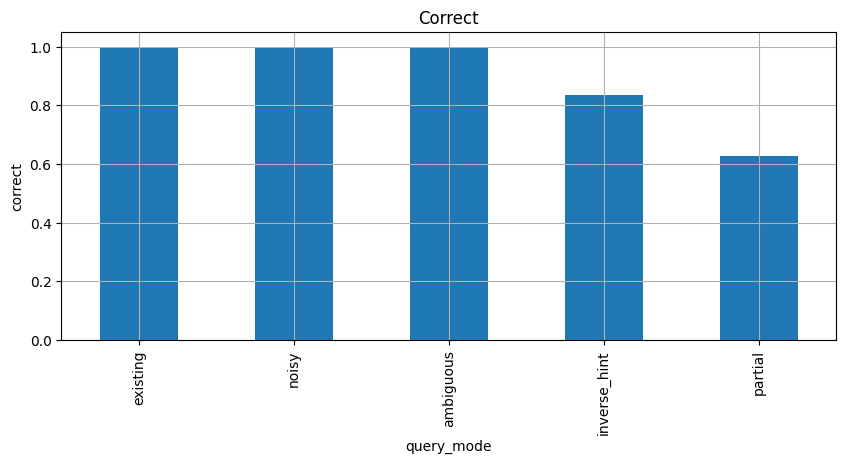

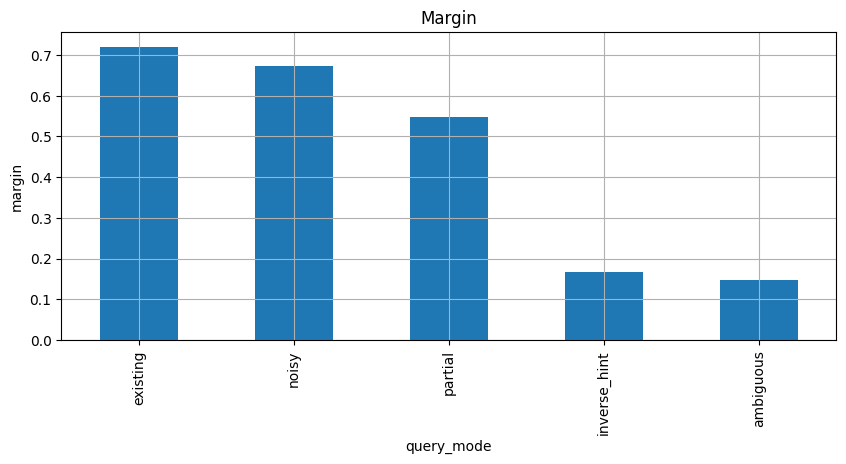

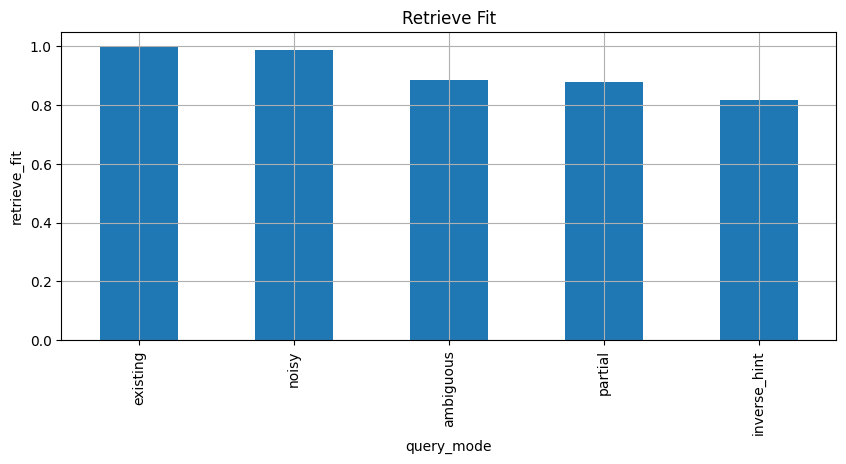

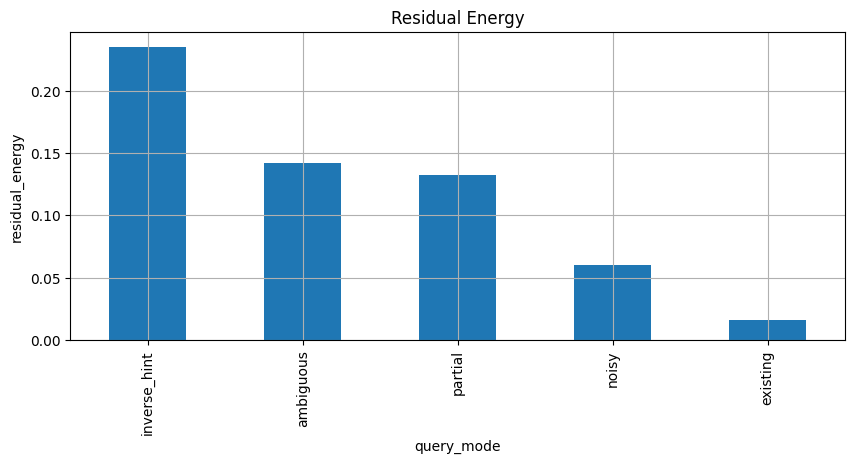

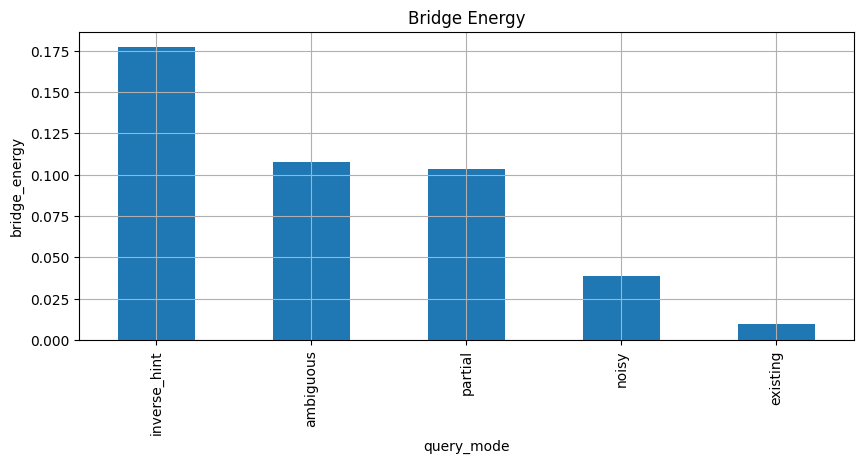

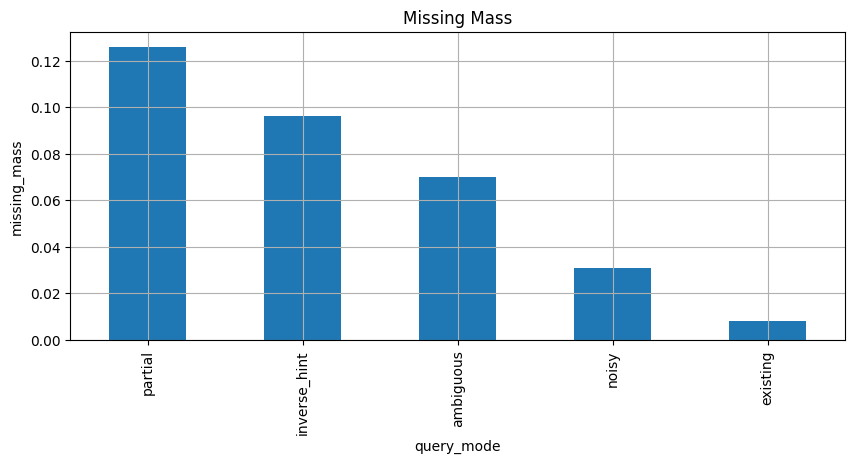

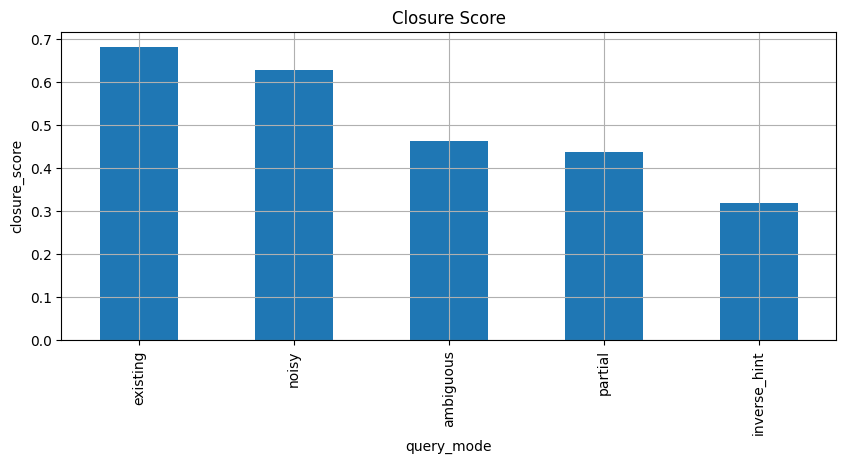

In [12]:

metrics = ["correct", "margin", "retrieve_fit", "residual_energy", "bridge_energy", "missing_mass", "closure_score"]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    grouped = calibrated_eval.groupby("query_mode")[metric].mean().sort_values(ascending=False)
    grouped.plot(kind="bar")
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("query_mode")
    plt.ylabel(metric)
    plt.show()


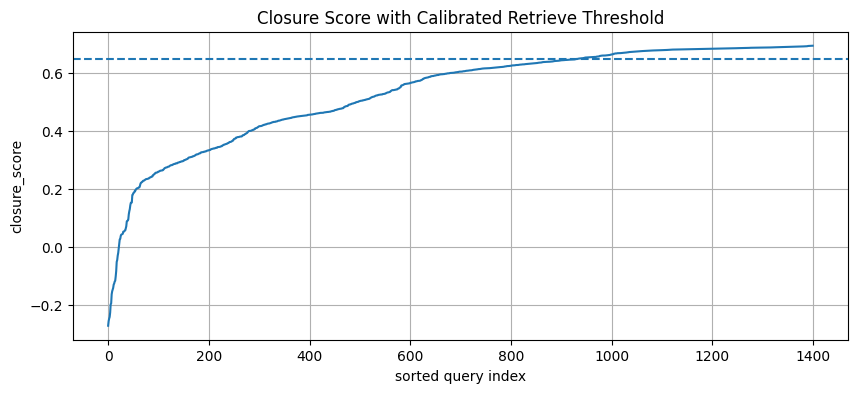

In [13]:

plt.figure(figsize=(10, 4))
score_series = calibrated_eval["closure_score"].sort_values().reset_index(drop=True)
plt.plot(score_series.values)
plt.axhline(retrieve_threshold, linestyle="--")
plt.title("Closure Score with Calibrated Retrieve Threshold")
plt.xlabel("sorted query index")
plt.ylabel("closure_score")
plt.show()



## Practical readout

This notebook proves the next control move:

- do not let retrieve/grow be only a hard local rule
- compute a closure score
- calibrate the split to the operating ratio you want

Here the operating target is:

- **35% retrieve**
- **65% grow**

So the triad becomes:

$$
Q \to (\text{best closure},\ \text{missing complement},\ \text{declared value},\ \text{mode})
$$

where `mode` is now explicitly calibrated.
